In [ ]:
# import libraries & components
import os, gc, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [ ]:
print(tf.__version__)
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

# mixed precision for more RAM on GPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('float32')

# call dataset & settings
DATA_DIR = "/content/drive/MyDrive/Data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16   # drop to 8 if RAM is still tight
RESULTS_CSV = "results_table.csv"

# ensure output dir exists
os.makedirs("/content/outputs", exist_ok=True)

2.19.0


In [ ]:
# definitions
def load_split(subdir, shuffle=False):
    ds = keras.utils.image_dataset_from_directory(
        os.path.join(DATA_DIR, subdir),
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED
    )
    return ds

train_raw = load_split("train", shuffle=True)
val_raw   = load_split("valid",   shuffle=False)
test_raw  = load_split("test",  shuffle=False)

CLASS_NAMES = train_raw.class_names
N_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

# stack grayscale images to 3 RGB channels
def ensure_rgb(x):
    # x is float32 [0..255], shape (B,H,W,3 or 1)
    return tf.image.grayscale_to_rgb(x) if x.shape[-1] == 1 else x

# light augmentations (good for clinical ds)
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="aug")

# preprocess pipelines (no in-RAM cache; prefetch only)
def prep(ds, training=False):
    def _map(x, y):
        x = ensure_rgb(x)
        return x, y
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2048, seed=SEED)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = prep(train_raw, training=True)
val_ds   = prep(val_raw, training=False)
test_ds  = prep(test_raw, training=False)

# compute class weights from train folder
train_counts = np.zeros(N_CLASSES, dtype=np.int64)
for _, y in keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"), labels="inferred", label_mode="int",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
):
    y = y.numpy()
    for i in range(N_CLASSES):
        train_counts[i] += np.sum(y == i)

total = train_counts.sum()
class_weights = {i: float(total / (N_CLASSES * train_counts[i])) for i in range(N_CLASSES)}
print("Train counts per class:", dict(zip(CLASS_NAMES, train_counts)))
print("Class weights:", class_weights)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.
Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Found 613 files belonging to 4 classes.
Train counts per class: {'adenocarcinoma': np.int64(195), 'large.cell.carcinoma': np.int64(115), 'normal': np.int64(148), 'squamous.cell.carcinoma': np.int64(155)}
Class weights: {0: 0.7858974358974359, 1: 1.3326086956521739, 2: 1.035472972972973, 3: 0.9887096774193549}


In [ ]:
# eval, grad-cam, logging
def evaluate_model(model, test_dataset, class_names, results_label, results_csv=RESULTS_CSV):
    # Collect preds/probs
    y_true, y_prob = [], []
    for xb, yb in test_dataset:
        pb = tf.nn.softmax(model(xb, training=False)).numpy()
        y_prob.append(pb)
        y_true.append(yb.numpy())
    y_prob = np.vstack(y_prob)
    y_true = np.concatenate(y_true)
    y_pred = y_prob.argmax(axis=1)

    # Reports
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    # Macro AUC (OvR)
    y_true_ovr = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        auc_macro = roc_auc_score(y_true_ovr, y_prob, average="macro", multi_class="ovr")
    except ValueError:
        auc_macro = np.nan

    acc = (y_true == y_pred).mean()
    f1_macro = report["macro avg"]["f1-score"]

    # Save/append results
    row = {"Model": results_label, "Acc": float(acc), "AUC_macro":
           float(auc_macro), "F1_macro": float(f1_macro)}
    df = pd.DataFrame([row])
    if not os.path.exists(results_csv):
        df.to_csv(results_csv, index=False)
    else:
        df.to_csv(results_csv, mode="a", header=False, index=False)

    print(f"[{results_label}] Acc={acc:.4f} AUC_macro={auc_macro:.4f} F1_macro={f1_macro:.4f}")
    print("Confusion matrix:\n", cm)
    return row, cm, (y_true, y_pred, y_prob)

# Grad-CAM (for CNN last conv layer)
def grad_cam(model, img_tensor, layer_name=None, class_index=None,
             target_size=(224,224)):
    # Pick last Conv2D if not provided
    if layer_name is None:
        conv_layers = [l.name for l in
                       model.layers if isinstance(l, tf.keras.layers.Conv2D)]
        if not conv_layers:
            raise ValueError("No Conv2D layer found for Grad-CAM.")
        layer_name = conv_layers[-1]

    grad_model = tf.keras.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor, training=False)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        class_index = int(class_index.numpy())
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)                          # (1,H,W,C)
    weights = tf.reduce_mean(grads, axis=(0,1,2))                  # (C,)
    cam = tf.reduce_sum(weights * conv_out, axis=-1)[0]            # (H,W)
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    # Resize with TensorFlow (no OpenCV issues)
    cam = tf.image.resize(cam[..., None], target_size,
                          method="bilinear")[..., 0]
    return cam.numpy().astype("float32"), class_index

def show_gradcam_grid(model, dataset, class_names, k=6, layer_name=None):
    count = 0
    for xb, yb in dataset.unbatch().take(200):
        img = xb.numpy().astype("uint8")
        it = tf.expand_dims(xb, 0)
        cam, ci = grad_cam(model, it, layer_name=layer_name)
        heatmap = (cam * 255).astype("uint8")
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

        plt.figure(figsize=(6,3))
        plt.subplot(1,2,1); plt.imshow(img); plt.axis("off");
        plt.title(f"True: {class_names[int(yb)]}")
        plt.subplot(1,2,2);
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB));
        plt.axis("off"); plt.title(f"Pred: {class_names[ci]}")
        plt.tight_layout(); plt.show()
        count += 1
        if count >= k: break

In [ ]:
#show_gradcam_grid
import matplotlib.pyplot as plt
import numpy as np

def show_gradcam_grid(model, dataset, class_names, k=6, layer_name=None, target_size=(224,224)):
    shown = 0
    for xb, yb in dataset.unbatch().take(200):   # unbatch = iterate single images
        img_uint8 = xb.numpy().astype("uint8")
        it = tf.expand_dims(xb, 0)

        cam, ci = grad_cam(model, it, layer_name=layer_name, target_size=target_size)

        plt.figure(figsize=(6,3))

        # original
        plt.subplot(1,2,1)
        plt.imshow(img_uint8)
        plt.axis("off")
        plt.title(f"True: {class_names[int(yb)]}")

        # Overlay CAM
        plt.subplot(1,2,2)
        plt.imshow(img_uint8)
        plt.imshow(cam, cmap="jet", alpha=0.4, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Pred: {class_names[int(ci)]}")

        plt.tight_layout()
        plt.show()

        shown += 1
        if shown >= k:
            break

In [ ]:
import tensorflow as tf, os, time
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("Policy:", tf.keras.mixed_precision.global_policy())

card_train = tf.data.experimental.cardinality(train_ds).numpy()
card_val   = tf.data.experimental.cardinality(val_ds).numpy()
print("Batches per epoch (train/val):", card_train, card_val)

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Policy: <DTypePolicy "float32">
Batches per epoch (train/val): 39 5


In [ ]:
# copying drive → local VM disk
!rsync -ah --info=progress2 "/content/drive/MyDrive/Data/" "/content/Data/"

# pointing dataset directory to the local copy
DATA_DIR = "/content/Data"


          1.19G 100%  323.11kB/s    0:59:52 (xfr#9554, to-chk=0/9734)


Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.4717 - loss: 1.1469 - val_accuracy: 0.2083 - val_loss: 1.3947
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5313 - loss: 0.9814 - val_accuracy: 0.2083 - val_loss: 1.5405
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5248 - loss: 0.9982 - val_accuracy: 0.2083 - val_loss: 1.6834
Epoch 4/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5038 - loss: 1.0597 - val_accuracy: 0.2083 - val_loss: 1.8487


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/keras/src

[CNN-baseline] Acc=0.2857 AUC_macro=0.6528 F1_macro=0.1111
Confusion matrix:
 [[  0   0   0 120]
 [  0   0   0  51]
 [  0   0   0  54]
 [  0   0   0  90]]


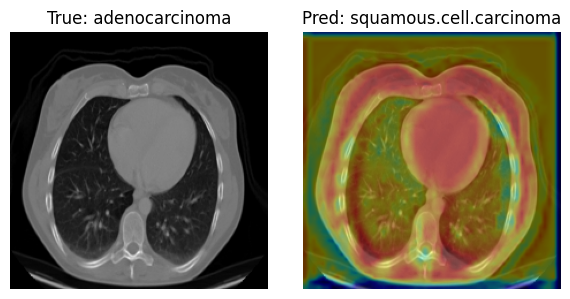

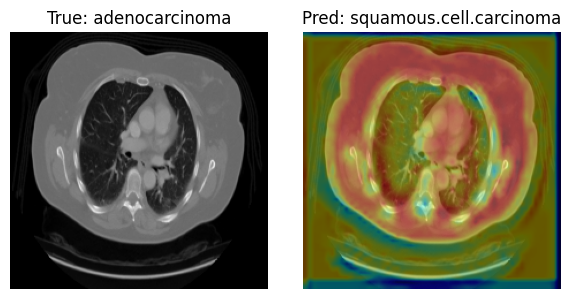

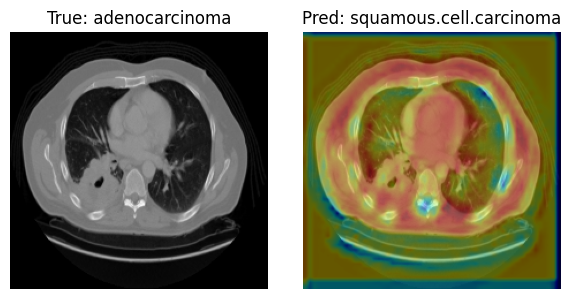

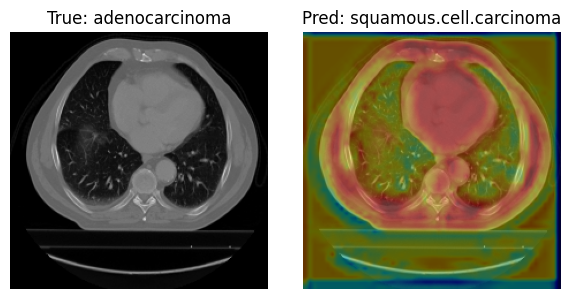

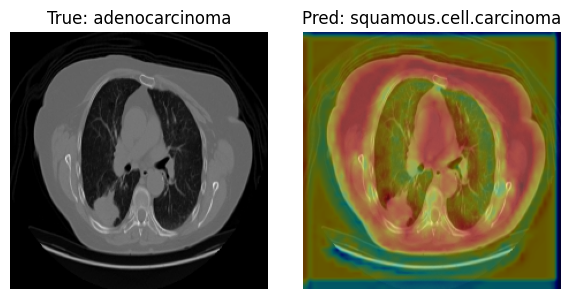

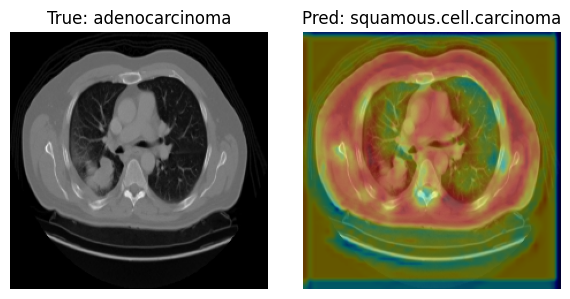

In [ ]:
# ======================================================
# Predictive Model 1 (Baseline CNN - scratch training)
# ======================================================
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_cnn(input_shape=(224,224,3), n_classes=4):
    inputs = keras.Input(shape=input_shape)
    x = data_aug(inputs)  # assumes data_aug defined above
    x = layers.Rescaling(1./255)(x)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.BatchNormalization()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.BatchNormalization()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.BatchNormalization()(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="cnn_baseline")

# ---- Build & compile ----
cnn = build_baseline_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), n_classes=N_CLASSES)
cnn.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ---- Callbacks ----
cb = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("cnn_baseline.best.keras", monitor="val_loss", save_best_only=True),
    keras.callbacks.CSVLogger("cnn_baseline_log.csv")
]

# ---- Training ----
history_cnn = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=cb
)

# ---- Evaluation ----
row_cnn, cm_cnn, _ = evaluate_model(
    cnn, test_ds, CLASS_NAMES,
    results_label="CNN-baseline",
    results_csv=RESULTS_CSV
)

# ---- Grad-CAM Visualization ----
show_gradcam_grid(cnn, test_ds, CLASS_NAMES, k=6)

In [ ]:
# ======================================================
# Predictive Model 2 (Transfer Learning - EfficientNetB0)
# ======================================================
from tensorflow.keras.applications import EfficientNetB0

# ---- Base model ----
base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base.trainable = False  # freeze for warmup

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_aug(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = base(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

tl = keras.Model(inputs, outputs, name="efficientnetb0_tl")

# ---- Warmup (frozen base) ----
tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_tl = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("efficientnetb0_tl.best.keras", monitor="val_loss", save_best_only=True),
    keras.callbacks.CSVLogger("efficientnetb0_tl_log.csv")
]

history_tl = tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=class_weights,
    callbacks=cb_tl
)

# ---- Fine-tune (unfreeze last 50% of layers) ----
for layer in base.layers[int(len(base.layers) * 0.5):]:
    layer.trainable = True

tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tl_ft = tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=cb_tl
)

# ---- Evaluation ----
row_tl, cm_tl, _ = evaluate_model(
    tl, test_ds, CLASS_NAMES,
    results_label="EfficientNetB0-TL",
    results_csv=RESULTS_CSV
)

# ---- Grad-CAM Visualization ----
show_gradcam_grid(tl, test_ds, CLASS_NAMES, k=6)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.2952 - loss: 1.4179 - val_accuracy: 0.5694 - val_loss: 1.0090
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6306 - loss: 0.8659 - val_accuracy: 0.5417 - val_loss: 0.8612
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6457 - loss: 0.7924 - val_accuracy: 0.5417 - val_loss: 0.8492
Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.5346 - loss: 1.1267 - val_accuracy: 0.5278 - val_loss: 0.8704
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7554 - loss: 0.7638 - val_accuracy: 0.5556 - val_loss: 0.8214
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.8559 - loss: 0.5244 - val_accuracy: 0.6389 - val_loss: 0.7598
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8920 - loss: 0.3933 - val_accuracy: 0.7361 - val_loss: 0.6870
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0

ValueError: No Conv2D layer found for Grad-CAM.

In [ ]:
# autoML - bounded search for after tx learning results
!pip -q install autokeras
import autokeras as ak
import numpy as np, os, pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import tensorflow as tf

def ds_to_numpy(ds):
    xs, ys = [], []
    for xb, yb in ds:
        xs.append(xb.numpy())
        ys.append(yb.numpy())
    return np.concatenate(xs), np.concatenate(ys)

# Rebuild lightweight ds for conversion (same prep you used elsewhere)
train_np_ds = prep(load_split("train", shuffle=True), training=True)
val_np_ds   = prep(load_split("valid", shuffle=False))
test_np_ds  = prep(load_split("test", shuffle=False))

x_tr, y_tr = ds_to_numpy(train_np_ds)
x_va, y_va = ds_to_numpy(val_np_ds)

ak_clf = ak.ImageClassifier(
    overwrite=True,
    max_trials=6,          # bounded search
    seed=SEED,
    project_name="autokeras_ct"
)

ak_clf.fit(
    x_tr, y_tr,
    validation_data=(x_va, y_va),
    epochs=8,
    class_weight=class_weights,
    verbose=1
)

# ---- INSPECTION: what AutoKeras chose ----
ak_clf.tuner.results_summary()
best_trial = ak_clf.tuner.oracle.get_best_trials(num_trials=1)[0]
print("\nBest Trial Hyperparameters:\n", best_trial.hyperparameters.values)

best = ak_clf.export_model()
print("\nBest Model Summary:\n")
best.summary()
best.save("autokeras_best_model.keras")

# ---- Evaluate on test ----
x_te, y_te = ds_to_numpy(test_np_ds)
y_prob = tf.nn.softmax(best.predict(x_te, verbose=0)).numpy()
y_pred = y_prob.argmax(1)

report = classification_report(y_te, y_pred, target_names=CLASS_NAMES,
                               digits=4, output_dict=True)
y_true_ovr = label_binarize(y_te, classes=list(range(N_CLASSES)))

try:
    auc_macro = roc_auc_score(y_true_ovr, y_prob, average="macro",
                              multi_class="ovr")
except ValueError:
    auc_macro = float("nan")

row_auto = {
    "Model": "AutoML-best",
    "Acc": float((y_te == y_pred).mean()),
    "AUC_macro": float(auc_macro),
    "F1_macro": float(report["macro avg"]["f1-score"])
}

pd.DataFrame([row_auto]).to_csv(
    RESULTS_CSV,
    mode="a",
    header=not os.path.exists(RESULTS_CSV),
    index=False
)

row_auto

Trial 6 Complete [00h 00m 18s]
val_loss: 0.9930718541145325

Best val_loss So Far: 0.6498053669929504
Total elapsed time: 00h 06m 25s
Epoch 1/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.3719 - loss: 1.6500 - val_accuracy: 0.4861 - val_loss: 1.1080
Epoch 2/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6853 - loss: 0.7620 - val_accuracy: 0.6528 - val_loss: 0.8805
Epoch 3/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8013 - loss: 0.5709 - val_accuracy: 0.6806 - val_loss: 0.7381
Epoch 4/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8446 - loss: 0.3869 - val_accuracy: 0.6944 - val_loss: 0.6393
Epoch 5/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8907 - loss: 0.2754 - val_accuracy: 0.7778 - val_loss: 0.5665
Epoch 6/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8944 - loss: 0.2429 - val_accuracy: 0.6667 - val_loss: 1.1569
Epoch 7/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8716 - loss: 0.2999 - val_accuracy: 0.8194 -

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (CastToFloat32) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 224, 224, 3)    │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 89888)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 89888)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       359,556 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1 (Softmax) │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,667 (1.55 MB)

 Trainable params: 406,660 (1.55 MB)

 Non-trainable params: 7 (32.00 B)

{'Model': 'AutoML-best',
 'Acc': 0.4888888888888889,
 'AUC_macro': 0.8097343244573355,
 'F1_macro': 0.4810821054210722}

In [ ]:
# show results table
pd.read_csv(RESULTS_CSV)

,Model,Acc,AUC_macro,F1_macro
0,CNN-baseline,0.285714,0.652776,0.111111
1,EfficientNetB0-TL,0.844444,0.966525,0.831217
2,AutoML-best,0.488889,0.809734,0.481082
